# Continuous Polarization-BSM Dataset Plots
All operational plots use BSM-only observables.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CANDIDATES = [
    Path('generated/polarization_bsm_60s'),
    Path('example/entanglement_swapping_validation/ai_bsm_dataset/generated/polarization_bsm_60s'),
]
RESULTS_DIR = next((path for path in CANDIDATES if (path / 'metadata.json').exists()), CANDIDATES[-1])
metadata = json.loads((RESULTS_DIR / 'metadata.json').read_text(encoding='utf-8'))
observable = pd.read_csv(RESULTS_DIR / 'bsm_observable_windows.csv')
labels = pd.read_csv(RESULTS_DIR / 'episode_labels.csv')
truth = pd.read_csv(RESULTS_DIR / 'hidden_truth.csv')
metadata


{'dataset_name': 'polarization_bsm_60s',
 'config_signature': '1e312217f4c1c1e325d9e75664bee492456f3f74b9f18e13184278b391109c9d',
 'episodes': 10000,
 'windows': 600000,
 'episode_duration_s': 60.0,
 'window_duration_s': 1.0,
 'continuous_timeline_per_episode': True,
 'fault_labels': ['healthy',
  'temperature_change',
  'polarization_drift',
  'spectral_detuning',
  'raman_noise',
  'attenuation_loss',
  'source_brightness_loss',
  'sync_issue',
  'source_clock_drift'],
 'ai_input_file': 'bsm_observable_windows.csv',
 'note': 'Only four BSM detector streams are model inputs; hidden truth is offline only.'}

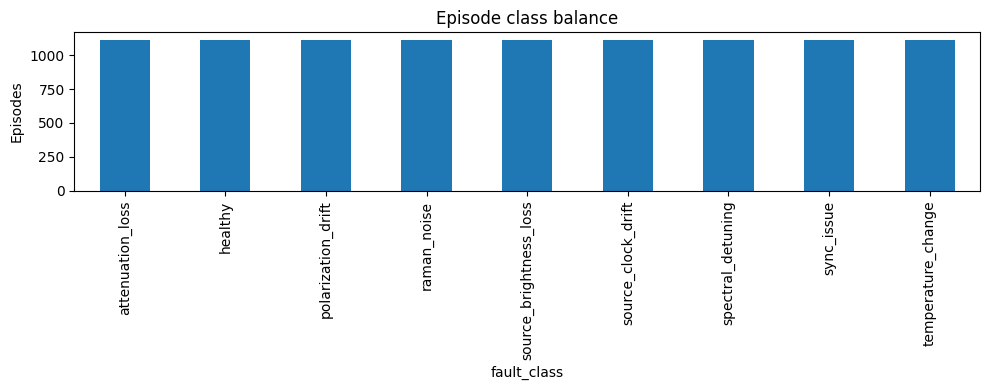

In [3]:
labels['fault_class'].value_counts().sort_index().plot.bar(figsize=(10,4))
plt.ylabel('Episodes'); plt.title('Episode class balance'); plt.tight_layout()


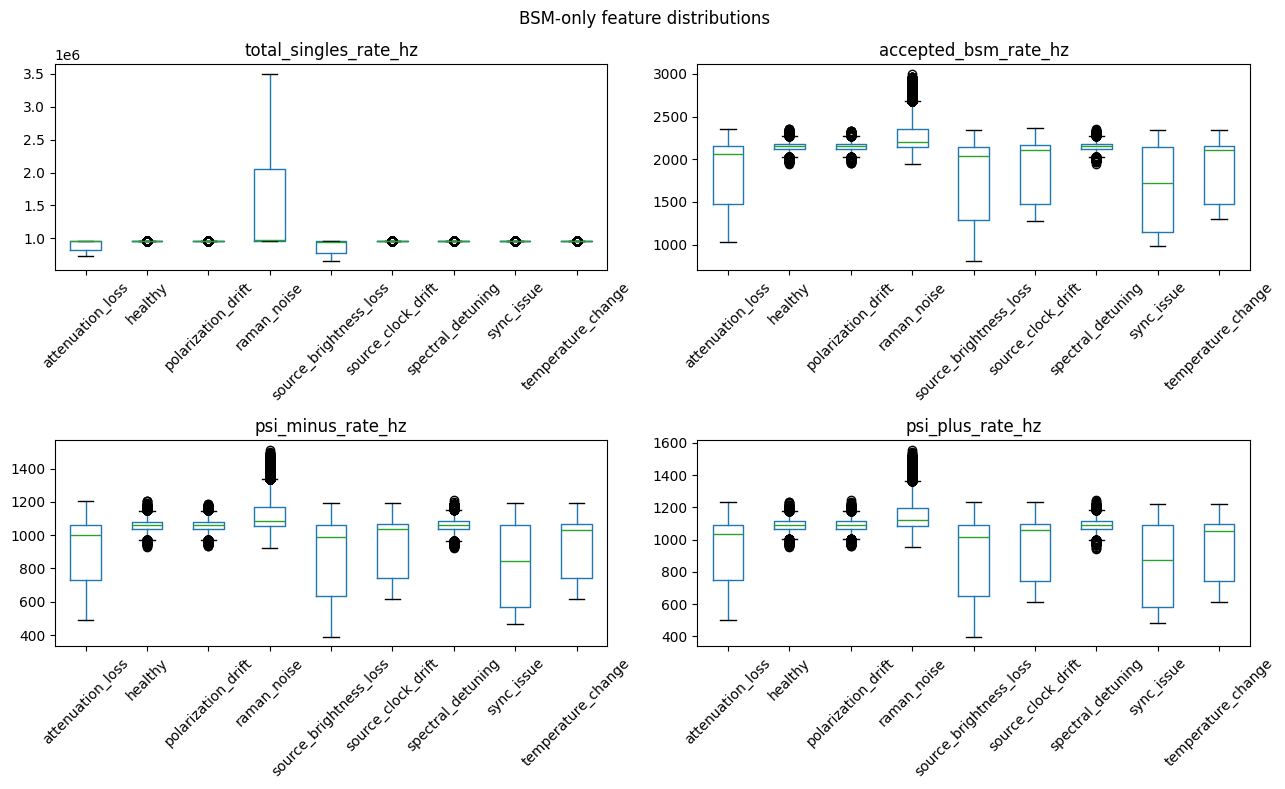

In [4]:
cols=['total_singles_rate_hz','accepted_bsm_rate_hz','psi_minus_rate_hz','psi_plus_rate_hz']
fig,axes=plt.subplots(2,2,figsize=(13,8))
for ax,col in zip(axes.ravel(),cols):
    observable.boxplot(column=col,by='fault_class',ax=ax,rot=45,grid=False)
    ax.set_title(col); ax.set_xlabel('')
fig.suptitle('BSM-only feature distributions'); plt.tight_layout()


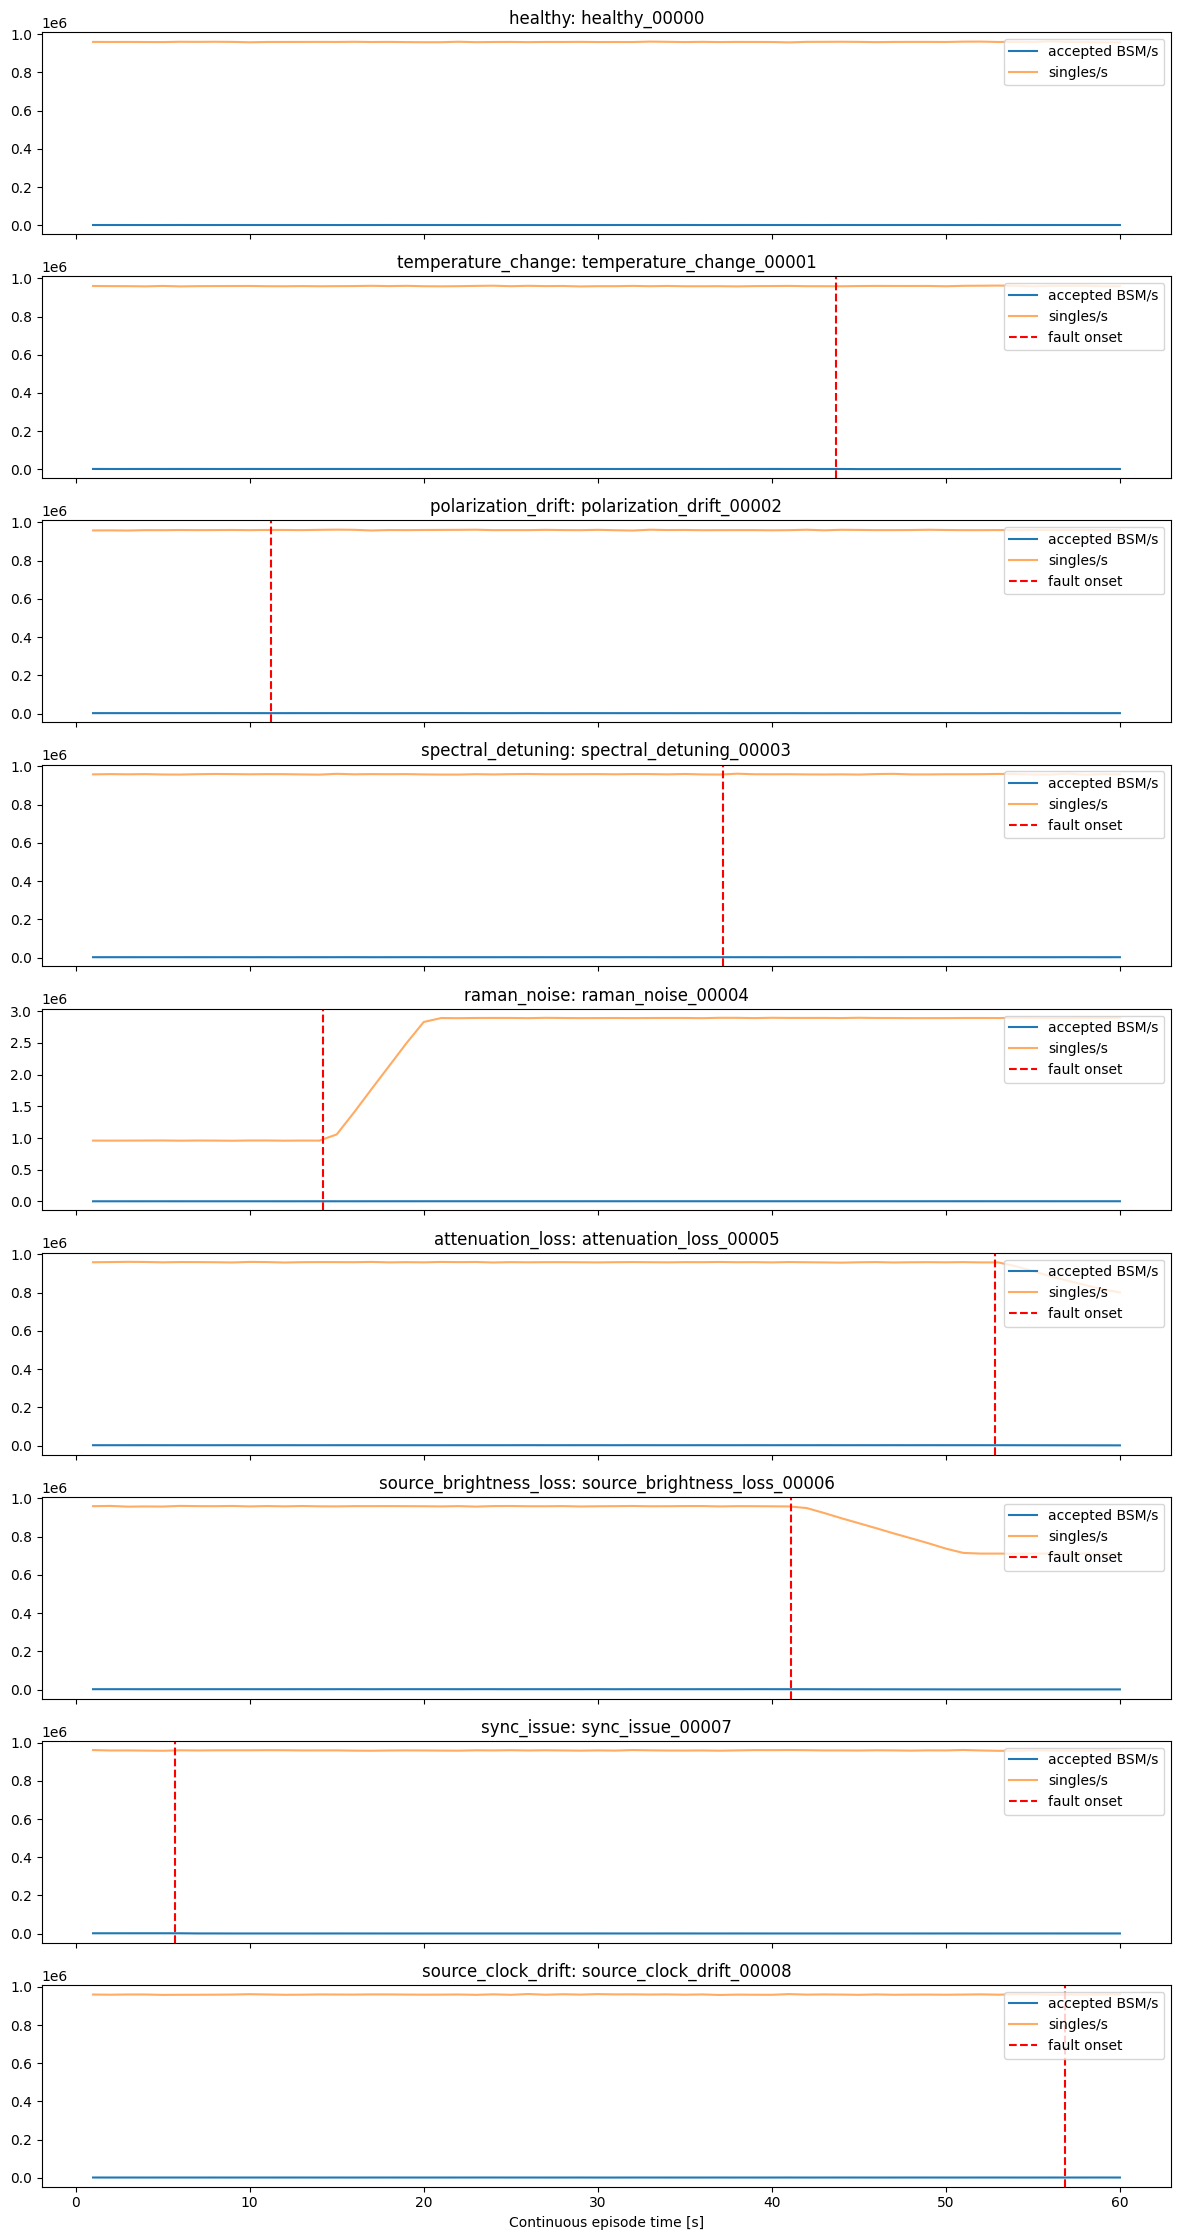

In [5]:
classes=labels['fault_class'].drop_duplicates()
fig,axes=plt.subplots(len(classes),1,figsize=(12,2.5*len(classes)),sharex=True)
for ax,fault in zip(np.atleast_1d(axes),classes):
    episode=labels.loc[labels.fault_class==fault,'episode_id'].iloc[0]
    data=observable[observable.episode_id==episode]
    onset=labels.loc[labels.episode_id==episode,'fault_onset_s'].iloc[0]
    ax.plot(data.window_end_s,data.accepted_bsm_rate_hz,label='accepted BSM/s')
    ax.plot(data.window_end_s,data.total_singles_rate_hz,label='singles/s',alpha=.65)
    if np.isfinite(onset) and onset <= metadata['episode_duration_s']:
        ax.axvline(onset,color='red',ls='--',label='fault onset')
    ax.set_title(f'{fault}: {episode}'); ax.legend(loc='upper right')
axes[-1].set_xlabel('Continuous episode time [s]'); plt.tight_layout()


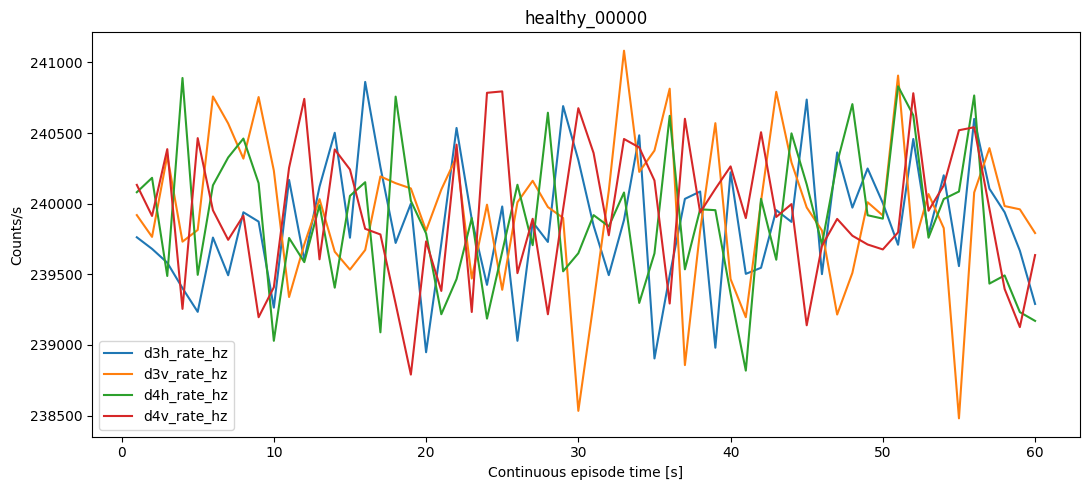

In [6]:
rates=['d3h_rate_hz','d3v_rate_hz','d4h_rate_hz','d4v_rate_hz']
episode=labels.episode_id.iloc[0]
data=observable[observable.episode_id==episode]
data.plot(x='window_end_s',y=rates,figsize=(11,5))
plt.ylabel('Counts/s'); plt.xlabel('Continuous episode time [s]'); plt.title(episode); plt.tight_layout()
